<a href="https://colab.research.google.com/github/tishhapatel/Advance-DataScience-and-ML/blob/main/lab10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install & Import Libraries

In [1]:
!pip install shap scikit-learn pandas matplotlib

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

Load Dataset (Malware-like Dataset)

In [2]:
np.random.seed(42)

# Features: file size, entropy, API calls, permissions
data = pd.DataFrame({
    "file_size": np.random.randint(100, 10000, 500),
    "entropy": np.random.uniform(1, 8, 500),
    "api_calls": np.random.randint(10, 200, 500),
    "permissions": np.random.randint(1, 10, 500),
    "source": np.random.choice([0,1], 500)  # sensitive attribute
})

# Label (malware = 1, benign = 0)
data["label"] = (data["entropy"] > 5).astype(int)

data.head()

,file_size,entropy,api_calls,permissions,source,label
0,7370,6.256097,16,5,0,1
1,960,6.281800,83,8,1,1
2,5490,1.721867,16,2,0,0
3,5291,7.317870,170,4,1,1
4,5834,4.536767,160,7,1,0


Train Logistic Regression Model

In [3]:
X = data.drop("label", axis=1)
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LogisticRegression()
model.fit(X_train, y_train)

# Accuracy
preds = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, preds))

Accuracy: 0.93


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


SHAP Explanation

/tmp/ipykernel_13816/1909827467.py:5: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


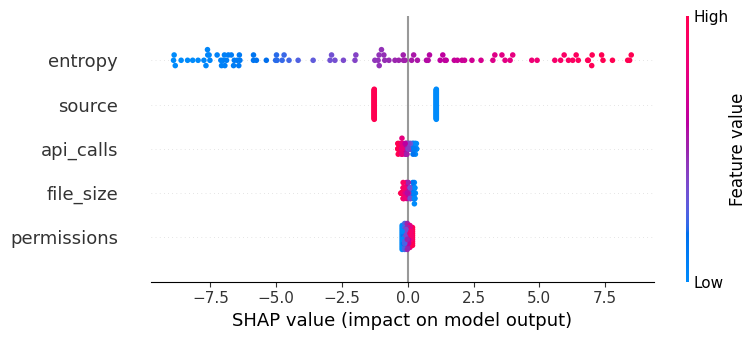

In [4]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test)

Individual Prediction Explanation

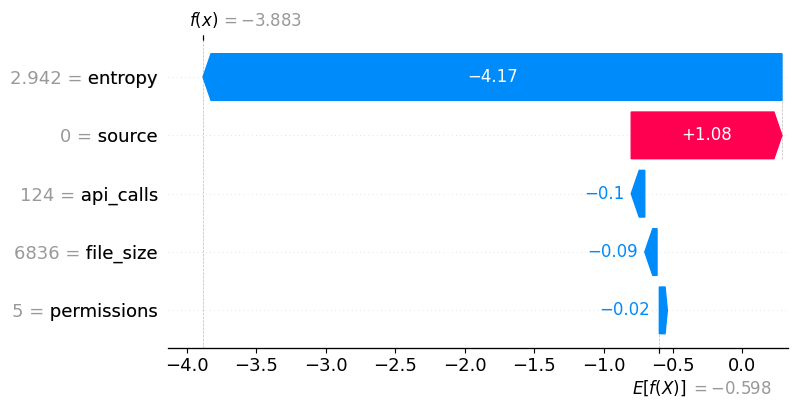

In [5]:
# Explain one sample
shap.plots.waterfall(shap_values[0])

Fairness Check (Demographic Parity)

In [6]:
# Predictions
X_test["prediction"] = preds

# Group-wise positive prediction rate
group0 = X_test[X_test["source"] == 0]["prediction"].mean()
group1 = X_test[X_test["source"] == 1]["prediction"].mean()

print("Group 0 Positive Rate:", group0)
print("Group 1 Positive Rate:", group1)

# Demographic parity difference
dp_diff = abs(group0 - group1)
print("Demographic Parity Difference:", dp_diff)

Group 0 Positive Rate: 0.4
Group 1 Positive Rate: 0.32
Demographic Parity Difference: 0.08000000000000002


Visualization of Fairness

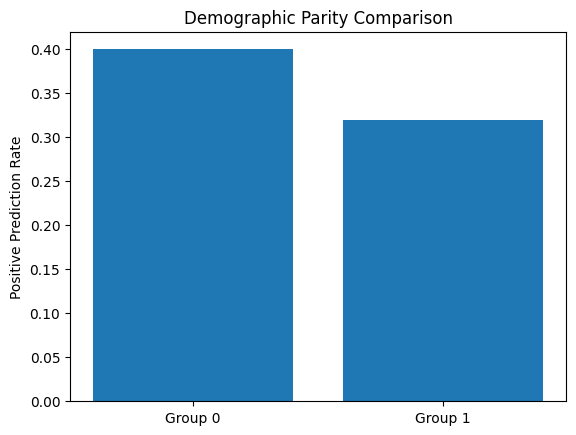

In [7]:
groups = ["Group 0", "Group 1"]
values = [group0, group1]

plt.bar(groups, values)
plt.title("Demographic Parity Comparison")
plt.ylabel("Positive Prediction Rate")
plt.show()